# Ejercicio 2: Predicción de niveles de glucosa en sangre

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

## 1. Carga de datos

In [2]:
df = pd.read_csv('glucosa_data.csv')
df.head()

,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730


In [3]:
df.describe()

,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.157000,24.963329,4.664500,139.630129
std,17.544494,3.983588,2.912247,27.342945
min,20.000000,10.586717,0.000000,43.415924
25%,34.000000,22.344522,2.000000,119.067583
50%,50.000000,25.028701,5.000000,139.967314
75%,64.000000,27.751081,7.000000,159.208487
max,79.000000,39.430227,9.000000,227.560693


## Verificación de calidad de datos

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print('Filas duplicadas:', df.duplicated().sum())


Valores nulos por columna:
Edad                0
IMC                 0
Actividad_Fisica    0
Nivel_Glucosa       0
dtype: int64
Filas duplicadas: 0


## 2. Entrenamiento del modelo

In [5]:
X = df[['Edad', 'IMC', 'Actividad_Fisica']]
y = df['Nivel_Glucosa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 1.23, 0.93,-2.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Edad','IMC','Actividad_Fisica']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.86
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## 3. Interpretación de coeficientes

In [6]:
for var, coef in zip(X.columns, model.coef_):
    print(f'{var}: {coef:.4f}')
print('Intercepto:', model.intercept_)

Edad: 1.2266
IMC: 0.9334
Actividad_Fisica: -2.0853
Intercepto: 65.86086530452525


## 4. Evaluación del modelo

In [7]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 233.6930
R2: 0.6814


## 5. Relación de cada variable con el nivel de glucosa

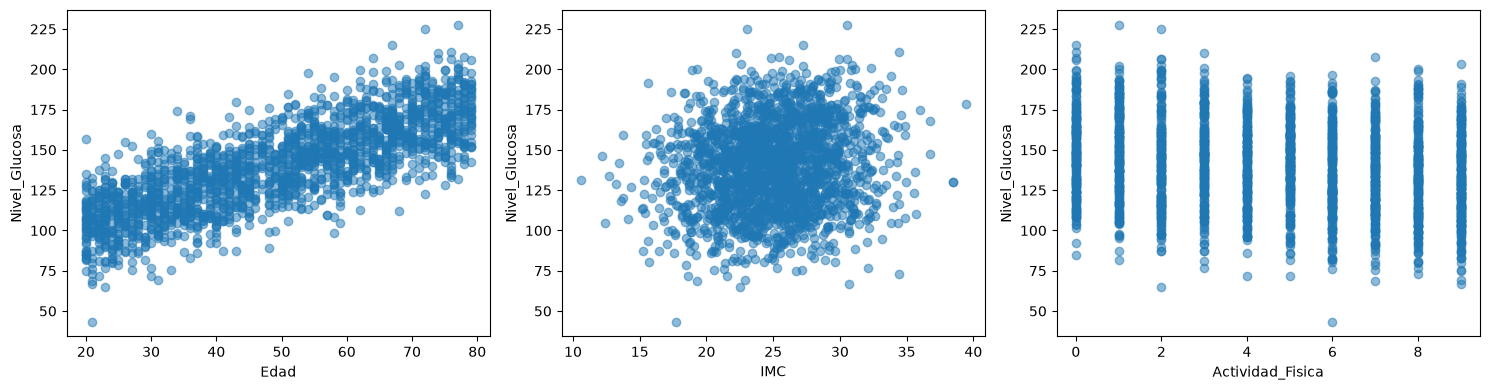

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, X.columns):
    ax.scatter(df[col], df['Nivel_Glucosa'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Nivel_Glucosa')
plt.tight_layout()
plt.show()

## 6. Variable con mayor impacto

In [9]:
df.corr()['Nivel_Glucosa'].drop('Nivel_Glucosa').sort_values(key=abs, ascending=False)

Edad                0.789792
Actividad_Fisica   -0.198395
IMC                 0.138318
Name: Nivel_Glucosa, dtype: float64

La variable con mayor correlación (en valor absoluto) con `Nivel_Glucosa`
es la que más impacta el resultado del modelo.

## 7. Exportar modelo

In [10]:
joblib.dump(model, 'modelo_glucosa.joblib')

['modelo_glucosa.joblib']